# Predicting Protein Prediction

Consider as starting point for this exercise a UCI Protein Structure. The dataset comes from the Critical Assessment of protein Structure Prediction experiments (CASP), which is a recurrent (biannual) initiative to predict protein structure from experimental data.

The dataset consists of roughly 45k entries with nine features and one target. 

The features essentially are calculated physicochemical descriptors:
- F1: Total surface area (Approximate exposed surface of the protein)
- F2: Non-polar exposed area (Hydrophobic surface)
- F3: Fraction of exposed nonpolar area (Ratio of hydrophobic and total surface)
- F4: Residue surface exposure (How much amino acids are exposed)
- F5: Secondary structure agreement (Measures consistency with expected structures (α-helices, β-sheets))
- F6: Pairwise distance features (Encodes distances between residues)
- F7: Compactness / packing (How tightly folded the protein is)
- F8: Structural energy-related feature (Proxy for physical plausibility)
- F9: Additional geometric descriptor (Captures global structure properties)

The target is the RMSD (Root Mean Squared Deviation) that describes the deviation of the predicted from the true protein structure. 

The aim of the exercise is to build a model to predict how accurate predicted structures would be based on calculated descriptors.

#### Tasks:
1) The data is somewhat abstract. Inspect it to see what can be expected of a potential model.
2) Create feature matrix and target vector.
3) Choose one Regression ML model, build it and optimise (consider scaling if the model class needs it)
4) Take note of the training and test time for your model (approximation is enough)
5) Whatever model you end up using, try to optimise for accuracy and minimal overfitting, use **MSE** for evaluating your model!
6) Respond to the discussion points.

#### Note:
Feel free in your choice in model class, everything covered in the course so far is on the table. You don't need to compare different ones, we will do that with the compiled results of all assignments.

In [14]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import seaborn as sns, time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

Load and investigate the data

In [2]:
df = pd.read_csv("CASP.csv")
df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


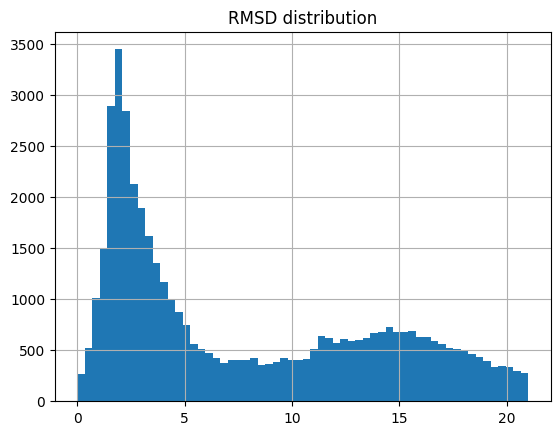

RMSD    1.000000
F3      0.374309
F4     -0.169771
F2      0.156895
F9      0.062830
F6     -0.036135
F1     -0.015087
F5     -0.013982
F7     -0.003339
F8      0.000344
Name: RMSD, dtype: float64

In [12]:
df['RMSD'].hist(bins=60); plt.title('RMSD distribution'); plt.show()
df.corr()['RMSD'].sort_values(key=abs, ascending=False)

Build feature matrix and target vector. Add scaling if needed for your model.

In [15]:
X = df.drop(columns=["RMSD"])
y = df["RMSD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [17]:
feature_cols = [f'F{i}' for i in range(1, 10)]
X = df[feature_cols].values
y = df['RMSD'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 36584  |  Test: 9146


Choose a Regression model, build, train and optimise

In [29]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

param_grid = {
    'n_estimators': [150, 250],  #100,200
    'max_depth': [None, 10, 20], #10,20
    'min_samples_split': [3, 5]  #2,5
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

In [30]:
grid_search.fit(X_train_scaled, y_train)
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Test MSE: {mse}")

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 3, 'n_estimators': 250}
Test MSE: 12.444859780468219


In [ ]:
gbr_base = GradientBoostingRegressor(random_state=42)
t0 = time.time()
gbr_base.fit(X_train, y_train)
train_time_base = time.time() - t0

mse_train_base = mean_squared_error(y_train, gbr_base.predict(X_train))
mse_test_base  = mean_squared_error(y_test,  gbr_base.predict(X_test))
print(f"Train MSE: {mse_train_base:.4f}  |  Test MSE: {mse_test_base:.4f}  |  Time: {train_time_base:.0f}s")

Train MSE: 21.2099  |  Test MSE: 22.3361  |  Time: 10s


In [32]:
param_dist = {
    'n_estimators':      [50, 100, 150, 200], #100, 200, 300, 400
    'max_depth':         [1, 2, 3, 4], #3, 4, 5, 6
    'learning_rate':     [0.05, 0.1, 0.15, 0.2],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [5, 10, 15], #2, 5, 10
    'max_features':      ['sqrt', 'log2', None],
}

search = RandomizedSearchCV(GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist, n_iter=30,
    scoring='neg_mean_squared_error', cv=5, n_jobs=-1, random_state=42)

t0 = time.time()
search.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.0f}s  |  Best CV MSE: {-search.best_score_:.4f}")
print(search.best_params_)

Done in 217s  |  Best CV MSE: 16.8289
{'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 5, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.2}


Evaluate your best model (MSE). Take note of training and test time (approximate).

In [31]:
start_train = time.time()
y_pred = best_rf.predict(X_test_scaled)
end_train = time.time()

mse = mean_squared_error(y_test, y_pred)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test MSE: {mse}")
print(f"Training Time: {end_train - start_train:.2f} seconds")
print(f"Prediction Time: {end_train - start_train:.2f} seconds")

Best Parameters: {'max_depth': None, 'min_samples_split': 3, 'n_estimators': 250}
Test MSE: 12.444859780468219
Training Time: 0.67 seconds
Prediction Time: 0.67 seconds


In [33]:
best = search.best_estimator_
y_pred_train = best.predict(X_train)
y_pred_test  = best.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)
print(f"Train MSE: {mse_train:.4f}  |  Test MSE: {mse_test:.4f}  |  RMSE: {mse_test**0.5:.4f}")

Train MSE: 13.8612  |  Test MSE: 16.8723  |  RMSE: 4.1076


#### Discussion points
1) Discuss your choice of model class.
- RFR: Dataset (9 calculated physicochemical descriptors for proteins) contains non-linear relations; connects patterns without requiring linear models
- GBR: Also able to deal with non-linear relations --> connects patterns by sequential iterating through trees.

2) How did you optimise your model? How did the best model perform?
Both models were optimised in the hope to reduce overfitting while trying to minimise time
- RFR: changing the parameters to n_estimators = [150, 250] ; 'min_samples_split': [3, 5] from the "standard settings" increased the necessary time by ca. 2 min, while not improving the MSE 12.39 to 12.44
- GBR: changing the parameters to from the "standard settings" decreased the time significantly, 3.5 min instead of 11.5min, but in expense of increasing the MSE from ca. 12.4 to 16.8.

3) How much time was needed for training the model and evaluations (approximation is enough)?
RFR = 4.5 min
GBR = 11.5 min

4) What limitations or shortcomings did you identify? What would be ideas to remedy or circumvent them?
- RFR: high / large memory usage if numbers of trees increase or they are too deep -> could perform more rigorous feature selection
- GBR: under-predicts extreme RMSD values; only limited features are considered -> context is lost -> focus on most important or check for additional features; overfitting at high RMSD -> weighted loss to give more error to high-error parts

5) In all its abstraction, what do the predictions of your model tell you?
The model predicts the difference between the actual experimental structure and the modelled protein structure, where a low predicted RMSD indicates a good prediction of the modelled structure. If the value is low (enough) the used model can be used and further optimised to get better predictions. 